# CLUSTERING
**GOAL**: find and extract the best clusters from the data.
1. Use K-Means algorithm to detect families groups with similar charatteristics.
2. View the clusters and interpret the results describing the main profiles.

In [94]:
import sys
import os
import import_ipynb

import numpy as np
import pandas as pd

SEED=48

In [95]:
# Add the folder containing "files.ipynb" to the Python path
sys.path.append(os.path.abspath("Utils"))

In [96]:
# Import the files notebook
import Utils.files as files

## IMPORT DATA

In [97]:
df = pd.read_csv("./Array_saved/X_without_null.csv")

In [98]:
df.head()

,Gender,AutonomousCommunity,SchoolOwnership,KindOfPlace,LivingUnit,DependentPersons,WorkConfinement,WorkConfinementsSecondAdult,ChildEarlyEducation1,ChildEarlyEducation2,...,SpaceGym,SpaceOther,SpaceNone,SpaceStreet,SpacePlots,SpaceParks,SpacePublic,SpaceSurroundingOther,SpaceSurroundingNone,ActivitiesOutside
0,2.0,PAIS VASCO,Público,2.0,2,0,1,1.0,0,1,...,0,0,0,0,0,1,1,0,0,2.0
1,2.0,PAIS VASCO,Público,2.0,2,0,1,1.0,0,1,...,0,1,0,0,0,1,0,0,0,3.0
2,2.0,PAIS VASCO,Público,2.0,2,1,1,0.0,0,1,...,1,0,0,1,0,0,1,0,0,3.0
3,2.0,PAIS VASCO,Concertado,2.0,2,0,1,1.0,0,0,...,1,0,0,0,1,1,0,0,0,3.0
4,2.0,PAIS VASCO,Público,2.0,2,0,0,1.0,0,1,...,1,1,0,0,0,0,1,0,0,2.0


### Convert string columns to numeric
This process will be needed later, when the representative instance for each cluster is shown.

In [99]:
from sklearn.preprocessing import OrdinalEncoder

#### 'AutonomousCommunity' column

In [100]:
oe = OrdinalEncoder().fit(df.loc[:, ["AutonomousCommunity"]])
oe.transform(df.loc[:, ["AutonomousCommunity"]])
# df.AutonomousCommunity = oe.transform(df.loc[:, ["AutonomousCommunity"]]) # make this after the encoding

array([[18.],
       [18.],
       [18.],
       ...,
       [ 8.],
       [ 8.],
       [15.]])

In [101]:
# The encoding is made in order with the mode
oe.categories_[0]

array(['ANDALUCÍA', 'ARAGÓN', 'ASTURIAS', 'CANARIAS', 'CANTABRIA',
       'CASTILLA LA MANCHA', 'CASTILLA Y LEÓN', 'CATALUÑA', 'CEUTA',
       'COMUNIDAD VALENCIANA', 'EXTREMADURA', 'GALICIA', 'ILLES BALEARS',
       'LA RIOJA', 'MADRID', 'MELILLA', 'MURCIA', 'NAVARRA', 'PAIS VASCO'],
      dtype=object)

In [102]:
AutonomousCommunity_dict = {}

for key in range(0, len(oe.categories_[0])):
    AutonomousCommunity_dict[ key ] = oe.categories_[0][key]

In [103]:
AutonomousCommunity_dict

{0: 'ANDALUCÍA',
 1: 'ARAGÓN',
 2: 'ASTURIAS',
 3: 'CANARIAS',
 4: 'CANTABRIA',
 5: 'CASTILLA LA MANCHA',
 6: 'CASTILLA Y LEÓN',
 7: 'CATALUÑA',
 8: 'CEUTA',
 9: 'COMUNIDAD VALENCIANA',
 10: 'EXTREMADURA',
 11: 'GALICIA',
 12: 'ILLES BALEARS',
 13: 'LA RIOJA',
 14: 'MADRID',
 15: 'MELILLA',
 16: 'MURCIA',
 17: 'NAVARRA',
 18: 'PAIS VASCO'}

#### 'SchoolOwnership' column

In [104]:
oe = OrdinalEncoder().fit(df.loc[:, ["SchoolOwnership"]])
oe.transform(df.loc[:, ["SchoolOwnership"]])
# df.SchoolOwnership = oe.transform(df.loc[:, ["SchoolOwnership"]]) # make this after the encoding

array([[2.],
       [2.],
       [2.],
       ...,
       [2.],
       [1.],
       [2.]])

In [105]:
oe.categories_[0]

[array(['Concertado', 'Privado', 'Público'], dtype=object)]

In [106]:
SchoolOwnership_dict = {}

for key in range(0, len(oe.categories_[0])):
    SchoolOwnership_dict[ key ] = oe.categories_[0][key]

## ENCODING

In [107]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [108]:
# This list contains only features that are categorical
nominal_col = list( df.loc[:, 'Gender':'ChildrenSpecialNeeds'].columns.drop('LivingUnit') )
nominal_col.extend( list( df.loc[:, 'WorkloadChange':'HouseworkMore'].columns ) )
nominal_col.extend( list( df.loc[:, 'Reconciling':'InterruptChildren'].columns ) )
nominal_col.extend( list( df.loc[:, 'Bedtime':'ChildMissTeacher'].columns ) )
nominal_col.extend( list( df.loc[:, 'ChallengeContent':'ChallengeAny'].columns ) )
nominal_col.extend( list( df.loc[:, 'FamiliesCollaboration':'ActivitiesOutside'].columns ) )

# This list contains only features that are ordinal
ordinal_col = list(["LivingUnit"])
ordinal_col.extend( list( df.loc[:, 'Sleep':'Sex'].columns ) )
ordinal_col.extend( list( df.loc[:, 'InterruptChildrenFrequency':'ChildrenSchookwork'].columns ) )
ordinal_col.extend( list( df.loc[:, 'HelpOnline':'ParentsCommunicationReturn'].columns ) )
ordinal_col.extend( list( df.loc[:, 'PriorityCustody':'PriorityEmotional'].columns ) )

In [109]:
transformer = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(), nominal_col)
], sparse_threshold=0, remainder="passthrough")

In [110]:
X_transformed = pd.DataFrame(transformer.fit_transform( df ), columns=transformer.get_feature_names_out())

In [111]:
X_transformed.head()

,ohe__Gender_1.0,ohe__Gender_2.0,ohe__AutonomousCommunity_ANDALUCÍA,ohe__AutonomousCommunity_ARAGÓN,ohe__AutonomousCommunity_ASTURIAS,ohe__AutonomousCommunity_CANARIAS,ohe__AutonomousCommunity_CANTABRIA,ohe__AutonomousCommunity_CASTILLA LA MANCHA,ohe__AutonomousCommunity_CASTILLA Y LEÓN,ohe__AutonomousCommunity_CATALUÑA,...,remainder__ChildrenSchookwork,remainder__HelpOnline,remainder__SchoolCommunication,remainder__ParentsGroups,remainder__ParentsCommunicationReturn,remainder__PriorityCustody,remainder__PriorityContent,remainder__PriorityAutonomy,remainder__PrioritySocialisation,remainder__PriorityEmotional
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,2.0,3.0,2.0,1.0,3.0,3.0,2.0,2.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,2.0,2.0,4.0,2.0,2.0,3.0,2.0,2.0,2.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,2.0,3.0,3.0,3.0,1.0,3.0,3.0,3.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,3.0,3.0,4.0,2.0,2.0,2.0,3.0,3.0,3.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,2.0,3.0,3.0,2.0,1.0,3.0,3.0,3.0,3.0


In [112]:
X_transformed.to_csv(path_or_buf="./Array_saved/X_embedded.csv", index=False)

## 3. Dimensionality Reduction

In [113]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.manifold import TSNE
import umap

In [114]:
pca = PCA(n_components=2, random_state=SEED)
Kpca = KernelPCA(n_components=2, random_state=SEED, kernel='rbf', gamma=0.1)
tsne = TSNE(n_components=2, random_state=SEED)
reducer = umap.UMAP()

X_pca = pca.fit_transform(X_transformed)
X_Kpca = Kpca.fit_transform(X_transformed)
X_tsne = tsne.fit_transform(X_transformed)
X_umap = reducer.fit_transform(X_transformed)

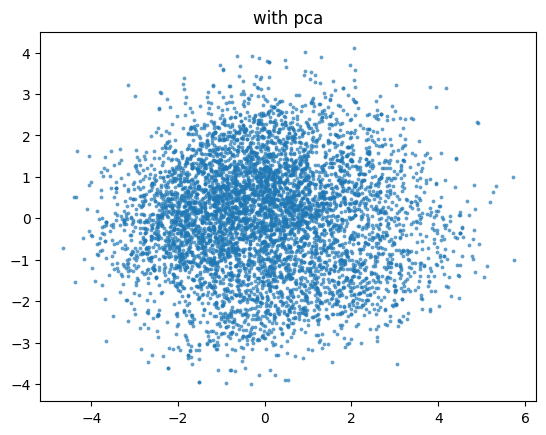

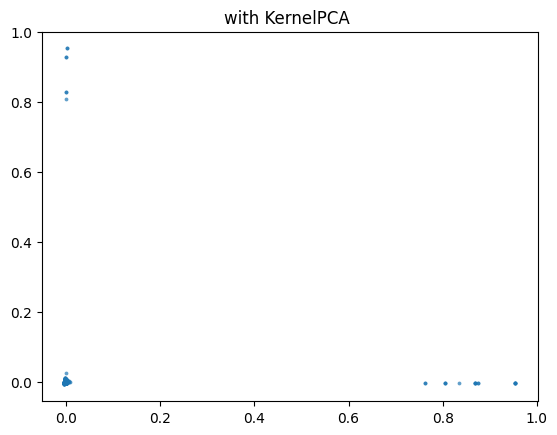

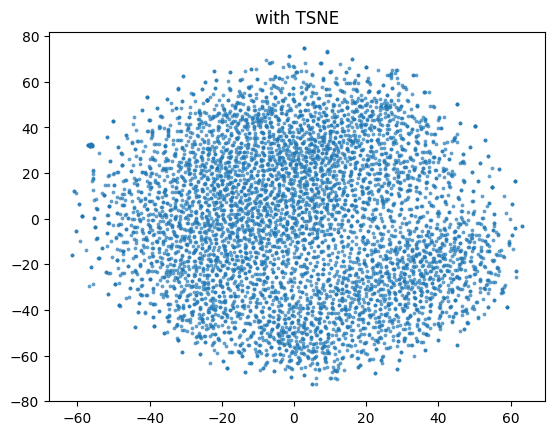

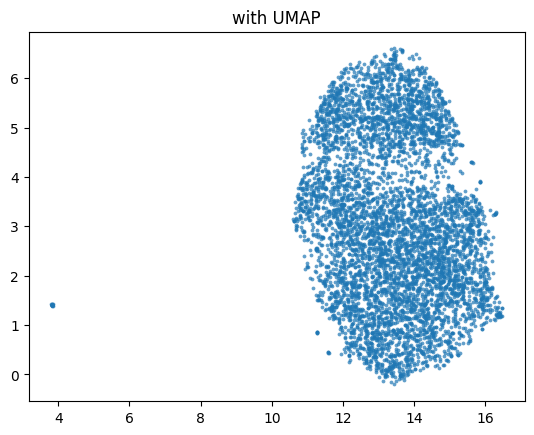

In [115]:
plt.figure(1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], marker=".", s=30, lw=0, alpha=0.7)
plt.title("with pca")

plt.figure(2)
plt.scatter(X_Kpca[:, 0], X_Kpca[:, 1], marker=".", s=30, lw=0, alpha=0.7)
plt.title("with KernelPCA ")

plt.figure(3)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], marker=".", s=30, lw=0, alpha=0.7)
plt.title("with TSNE")

plt.figure(4)
plt.scatter(X_umap[:, 0], X_umap[:, 1], marker=".", s=30, lw=0, alpha=0.7)
plt.title("with UMAP")

plt.show()

#### Last conversion
In this Area transform nominal values of 'AutonomousCommunity' and 'SchoolOwnership' columns in numeric value for extract the mode.

In [116]:
# For "AutonomousCommunity" column
oe = OrdinalEncoder().fit(df.loc[:, ["AutonomousCommunity"]])
df.AutonomousCommunity = oe.transform(df.loc[:, ["AutonomousCommunity"]])

# For "SchoolOwnership" column
oe = OrdinalEncoder().fit(df.loc[:, ["SchoolOwnership"]])
df.SchoolOwnership = oe.transform(df.loc[:, ["SchoolOwnership"]])


## 4. K-Means

In [117]:
import matplotlib.cm as cm

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

In [118]:
def make_KMeans (X, min_cluster=2, max_cluster=4):

    labels_matrix = np.ndarray((X.shape[0], max_cluster-min_cluster+1))
    index = 0

    for n_clusters in range(min_cluster, max_cluster+1):
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all lie within [-0.1, 1]
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator seed of 48 for reproducibility.
        clusterer = KMeans(n_clusters=n_clusters, random_state=SEED)
        cluster_labels = clusterer.fit_predict(X)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed clusters
        silhouette_avg = silhouette_score(X, cluster_labels)
        print(
            "For n_clusters =",
            n_clusters,
            "The average silhouette_score is :",
            silhouette_avg,
        )

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(X, cluster_labels)


        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(
            X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
        )

        # Labeling the clusters
        centers = clusterer.cluster_centers_ # TODO: attenzione i centri sono vettori con più di 2 feature 
        # Draw white circles at cluster centers
        ax2.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="o",
            c="white",
            alpha=1,
            s=200,
            edgecolor="k",
        )

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(
            "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
            % n_clusters,
            fontsize=14,
            fontweight="bold",
        )

        labels_matrix[:, index] = cluster_labels
        index += 1

    plt.show()

    return labels_matrix

### With PCA

For n_clusters = 2 The average silhouette_score is : 0.353030782296487
For n_clusters = 3 The average silhouette_score is : 0.33877202184390626
For n_clusters = 4 The average silhouette_score is : 0.34539953456767136


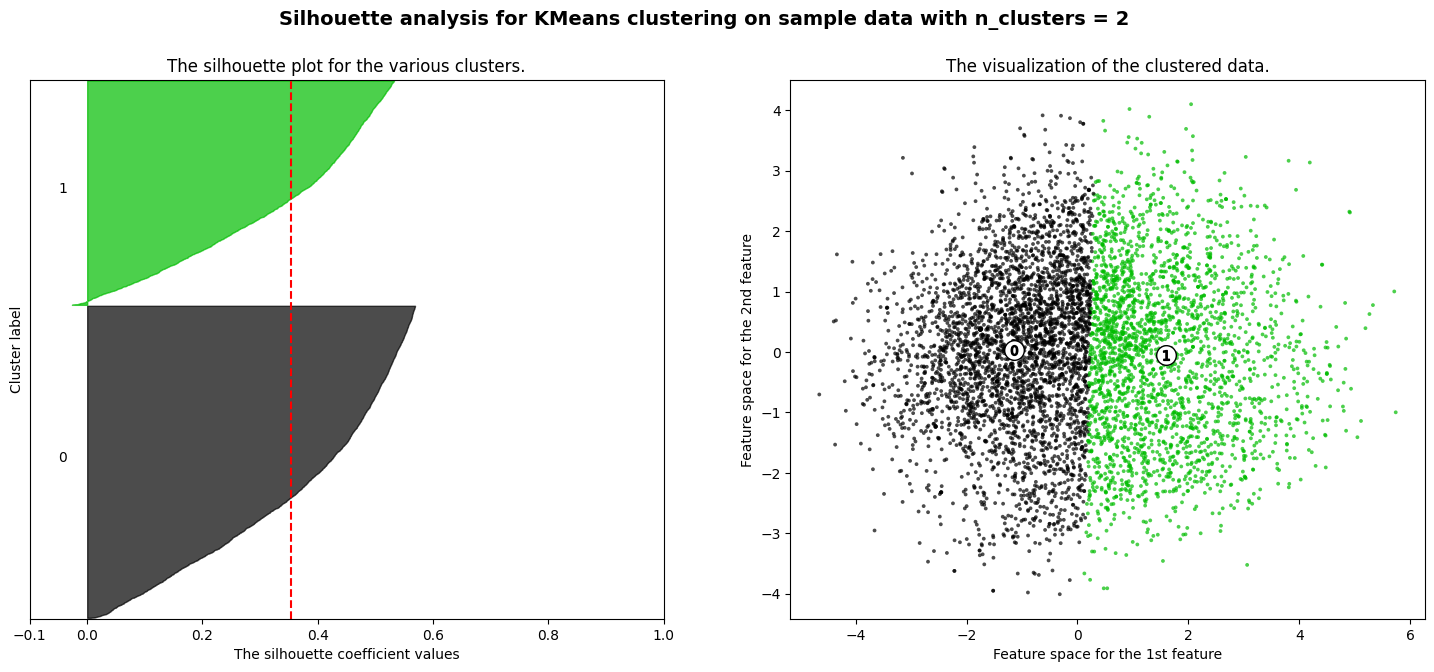

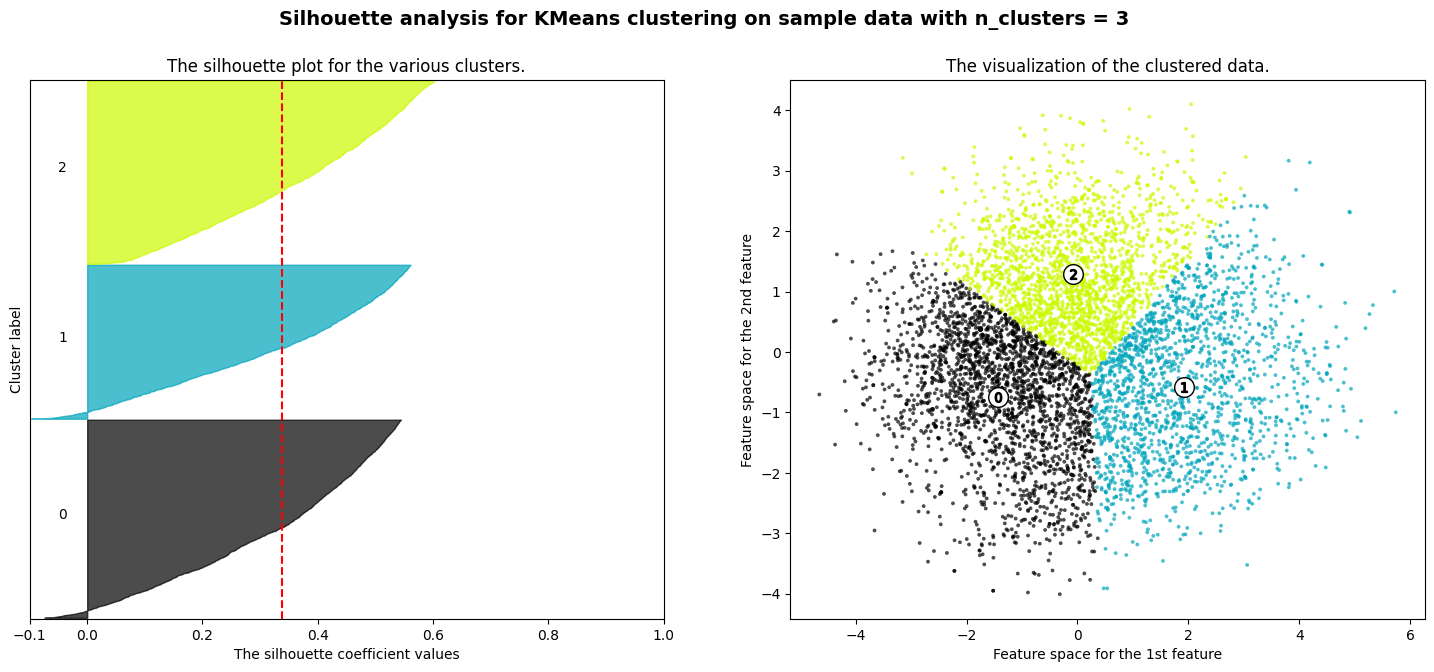

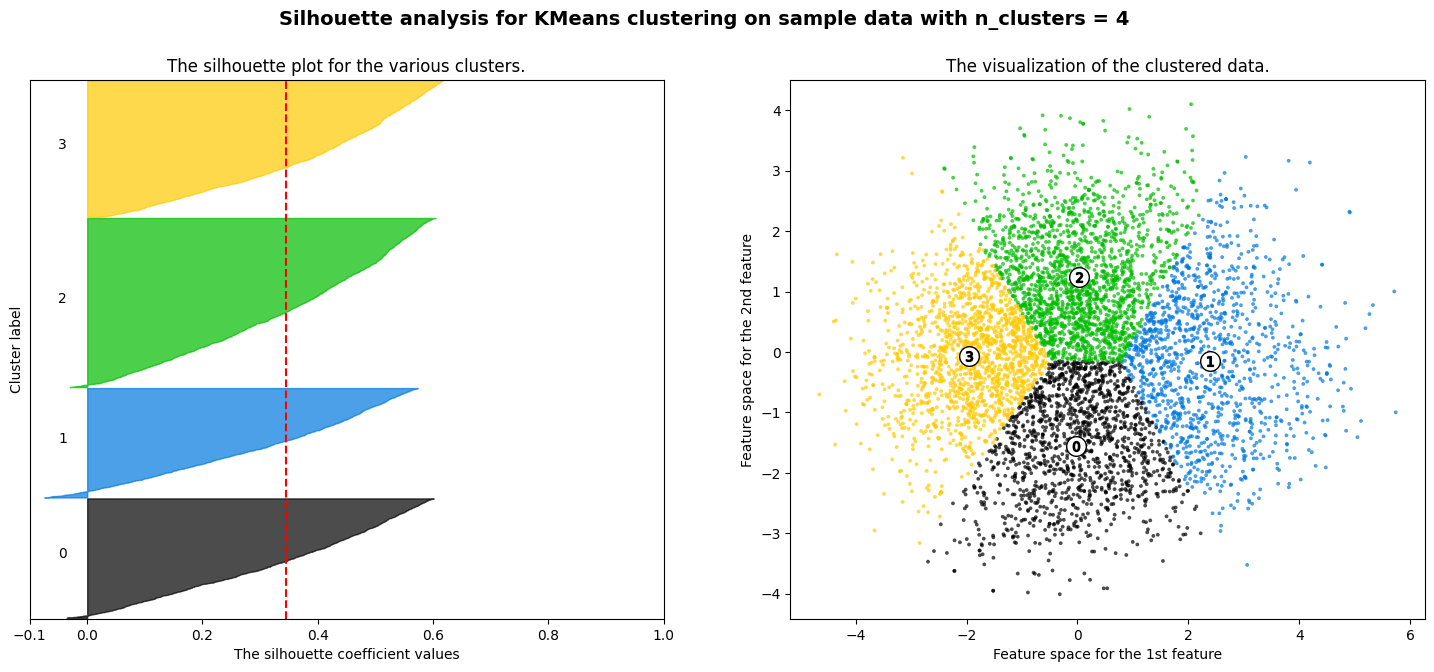

In [119]:
labels_matrix = make_KMeans(X_pca)

In [120]:
# Number of representatives (clusters)
NUM_RAP = 3

# Select labels for first configuration (number of cluster selected)
label = labels_matrix[:, NUM_RAP-2]
# Create a matrix where each rows is representative of a cluster
rappresentative_istance = np.ndarray( (NUM_RAP, df.shape[1]) )

for i in range(0, NUM_RAP ):

    # For each cluster take the mode instance
    rappresentative_istance[i, :] = df.loc[label==i, :].mode()

In [121]:
rappresentative_istance = pd.DataFrame(rappresentative_istance, columns=df.columns)
# Map the String values
rappresentative_istance.loc[:, "AutonomousCommunity"] = rappresentative_istance.loc[:, "AutonomousCommunity"].map(AutonomousCommunity_dict)
rappresentative_istance.loc[:, "SchoolOwnership"] = rappresentative_istance.loc[:, "SchoolOwnership"].map(SchoolOwnership_dict)

rappresentative_istance

C:\Users\gabry\AppData\Local\Temp\ipykernel_28312\3393922528.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['COMUNIDAD VALENCIANA' 'COMUNIDAD VALENCIANA' 'COMUNIDAD VALENCIANA']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rappresentative_istance.loc[:, "AutonomousCommunity"] = rappresentative_istance.loc[:, "AutonomousCommunity"].map(AutonomousCommunity_dict)
C:\Users\gabry\AppData\Local\Temp\ipykernel_28312\3393922528.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Público' 'Público' 'Público']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rappresentative_istance.loc[:, "SchoolOwnership"] = rappresentative_istance.loc[:, "SchoolOwnership"].map(SchoolOwnership_dict)


,Gender,AutonomousCommunity,SchoolOwnership,KindOfPlace,LivingUnit,DependentPersons,WorkConfinement,WorkConfinementsSecondAdult,ChildEarlyEducation1,ChildEarlyEducation2,...,SpaceGym,SpaceOther,SpaceNone,SpaceStreet,SpacePlots,SpaceParks,SpacePublic,SpaceSurroundingOther,SpaceSurroundingNone,ActivitiesOutside
0,2.0,COMUNIDAD VALENCIANA,Público,2.0,2.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0
1,2.0,COMUNIDAD VALENCIANA,Público,2.0,2.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0
2,2.0,COMUNIDAD VALENCIANA,Público,2.0,2.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0


In [122]:
# Show only the column with different values
mask_col_different = (rappresentative_istance.iloc[0, :] != rappresentative_istance.iloc[1, :]) | (rappresentative_istance.iloc[1, :] != rappresentative_istance.iloc[2, :])
rappresentative_istance.loc[:, mask_col_different]

,ChildEarlyEducation2,WorkloadChange,Sleep,Leisure,Sports,Friends,ExtendedFamily,Future,Sex,Reconciling,...,TechnologyUse,ChildPhysicalActivity,Irritability,Boredom,ChildLeavingHome,ChildMissTeacher,ChallengeAny,SpacePorch,SpaceDining,SpaceHall
0,0.0,3.0,2.0,1.0,1.0,2.0,2.0,3.0,2.0,2.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,3.0,2.0,2.0,3.0,3.0,3.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,3.0,2.0,2.0,2.0,2.0,3.0,4.0,3.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0


### With Kernel-PCA

For n_clusters = 3 The average silhouette_score is : 0.9982611492341075


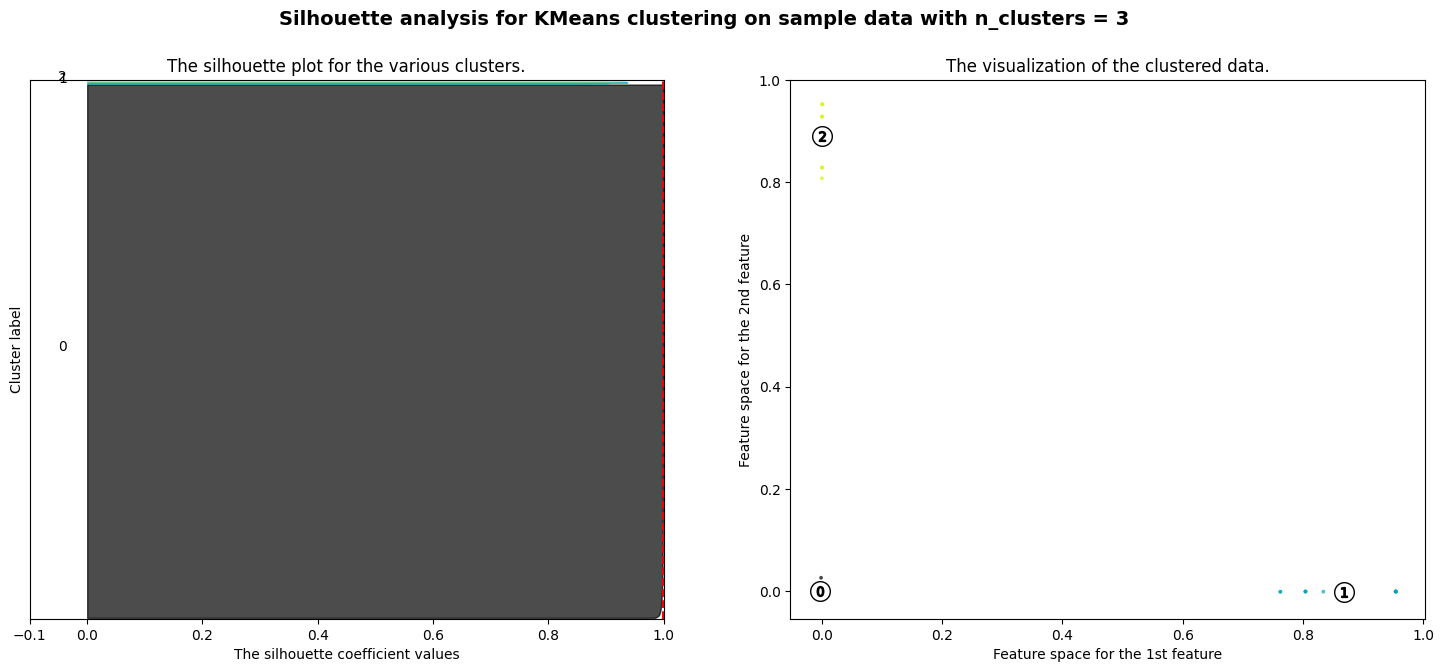

In [123]:
labels_matrix = make_KMeans(X_Kpca, min_cluster=3, max_cluster=3)

Distribution of the instances

In [124]:
NUM_RAP = 3

pd.Series(labels_matrix[:, NUM_RAP-3]).value_counts()

0.0    5992
1.0      17
2.0       7
Name: count, dtype: int64

In [125]:
# Select labels for first configuration (number of cluster selected
label = labels_matrix[:, NUM_RAP-3]
# Create a matrix where each rows is representative of a cluster
rappresentative_istance = np.ndarray( (NUM_RAP, df.shape[1]) )

for i in range(0, NUM_RAP ):

    # For each cluster take the mode instance
    rappresentative_istance[i, :] = df.loc[label==i, :].mode()

In [126]:
rappresentative_istance = pd.DataFrame(rappresentative_istance, columns=df.columns)
# Map the String values
rappresentative_istance.loc[:, "AutonomousCommunity"] = rappresentative_istance.loc[:, "AutonomousCommunity"].map(AutonomousCommunity_dict)
rappresentative_istance.loc[:, "SchoolOwnership"] = rappresentative_istance.loc[:, "SchoolOwnership"].map(SchoolOwnership_dict)

rappresentative_istance

C:\Users\gabry\AppData\Local\Temp\ipykernel_28312\3393922528.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['COMUNIDAD VALENCIANA' 'COMUNIDAD VALENCIANA' 'COMUNIDAD VALENCIANA']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rappresentative_istance.loc[:, "AutonomousCommunity"] = rappresentative_istance.loc[:, "AutonomousCommunity"].map(AutonomousCommunity_dict)
C:\Users\gabry\AppData\Local\Temp\ipykernel_28312\3393922528.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Público' 'Público' 'Privado']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rappresentative_istance.loc[:, "SchoolOwnership"] = rappresentative_istance.loc[:, "SchoolOwnership"].map(SchoolOwnership_dict)


,Gender,AutonomousCommunity,SchoolOwnership,KindOfPlace,LivingUnit,DependentPersons,WorkConfinement,WorkConfinementsSecondAdult,ChildEarlyEducation1,ChildEarlyEducation2,...,SpaceGym,SpaceOther,SpaceNone,SpaceStreet,SpacePlots,SpaceParks,SpacePublic,SpaceSurroundingOther,SpaceSurroundingNone,ActivitiesOutside
0,2.0,COMUNIDAD VALENCIANA,Público,2.0,2.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0
1,2.0,COMUNIDAD VALENCIANA,Público,0.0,2.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0
2,2.0,COMUNIDAD VALENCIANA,Privado,1.0,2.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [127]:
# Show only the column with different values
mask_col_different = (rappresentative_istance.iloc[0, :] != rappresentative_istance.iloc[1, :]) & (rappresentative_istance.iloc[1, :] != rappresentative_istance.iloc[2, :]) & (rappresentative_istance.iloc[0, :] != rappresentative_istance.iloc[2, :])
temp = rappresentative_istance.loc[:, mask_col_different]

In [128]:
temp

,KindOfPlace,WorkloadChange,ExtendedFamily
0,2.0,3.0,3.0
1,0.0,4.0,2.0
2,1.0,7.0,4.0


### With TSNE

For n_clusters = 2 The average silhouette_score is : 0.3928999
For n_clusters = 3 The average silhouette_score is : 0.3893066
For n_clusters = 4 The average silhouette_score is : 0.3701994


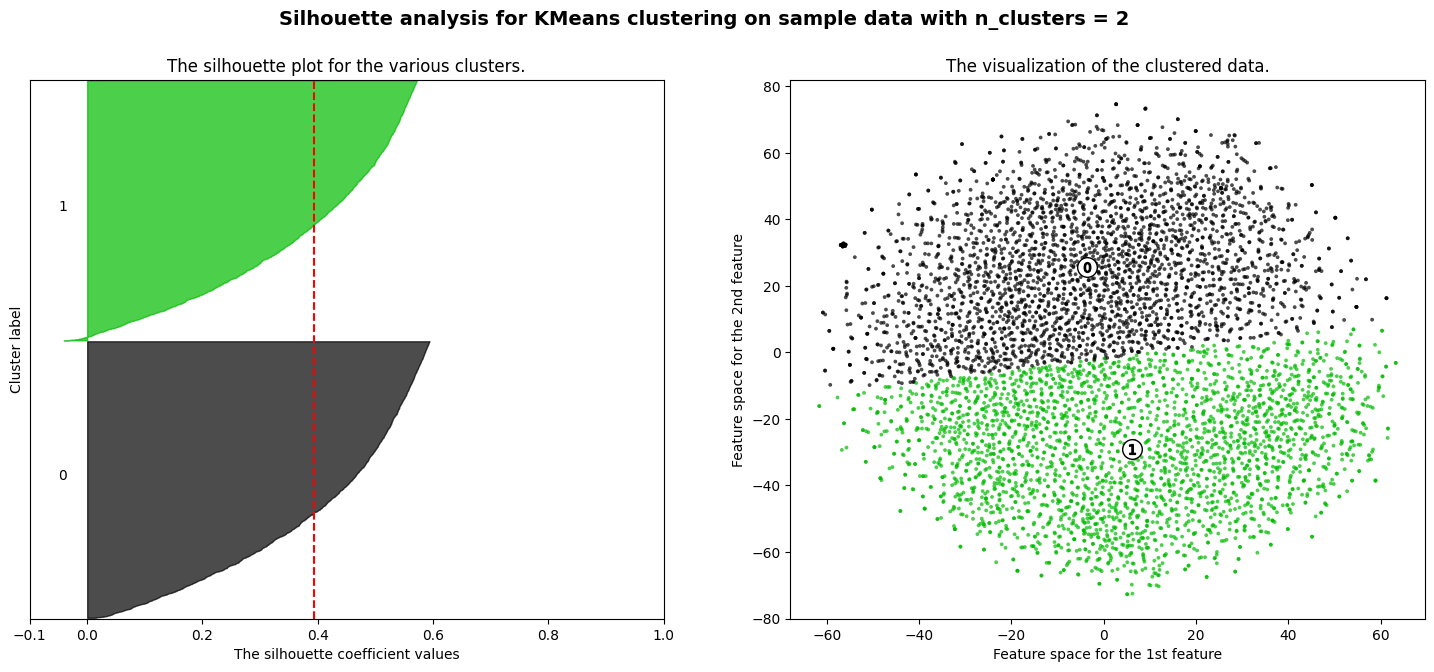

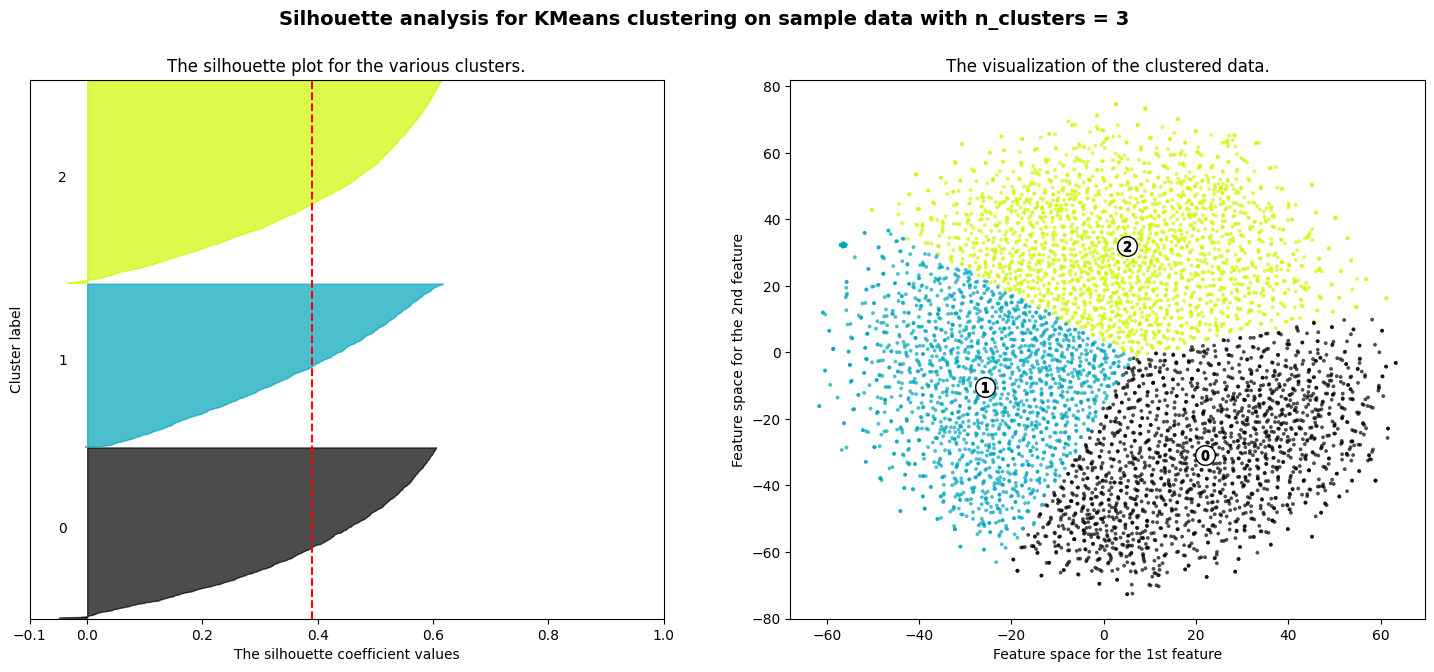

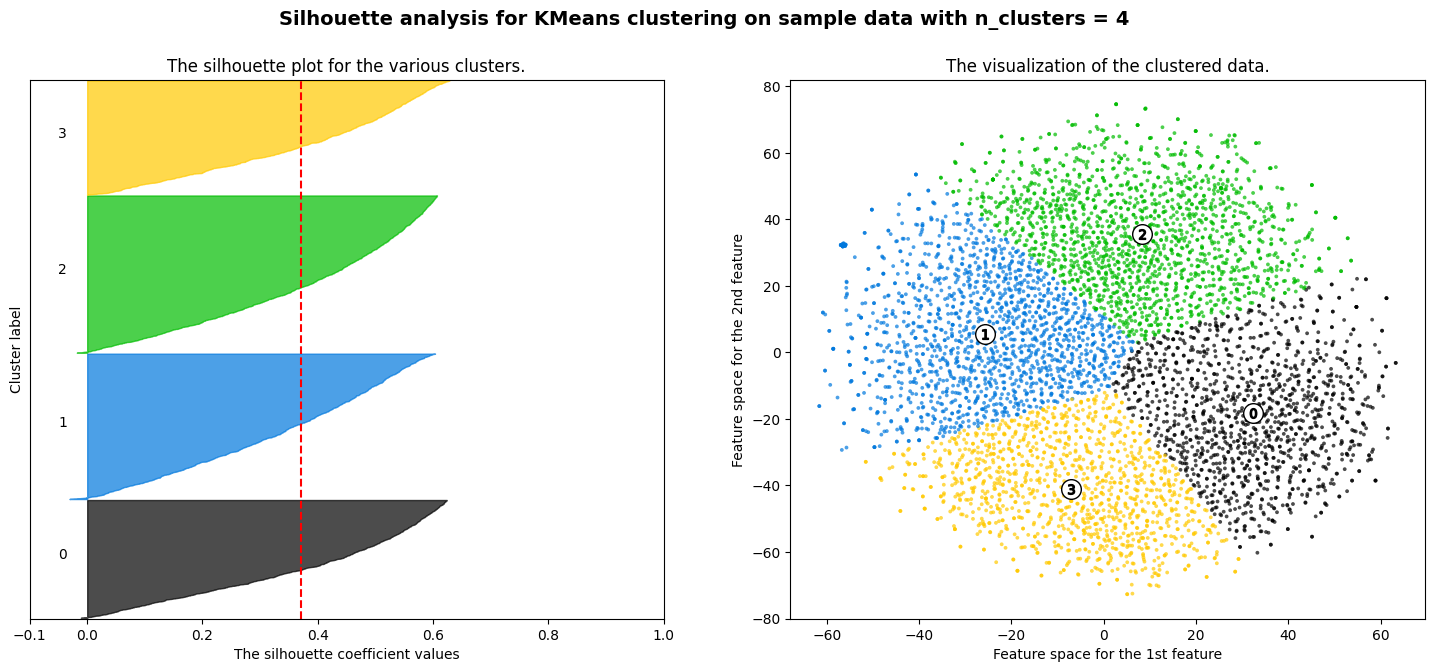

In [129]:
labels_matrix = make_KMeans(X_tsne)

### With UMAP

For n_clusters = 2 The average silhouette_score is : 0.42408392
For n_clusters = 3 The average silhouette_score is : 0.39942712
For n_clusters = 4 The average silhouette_score is : 0.39273468


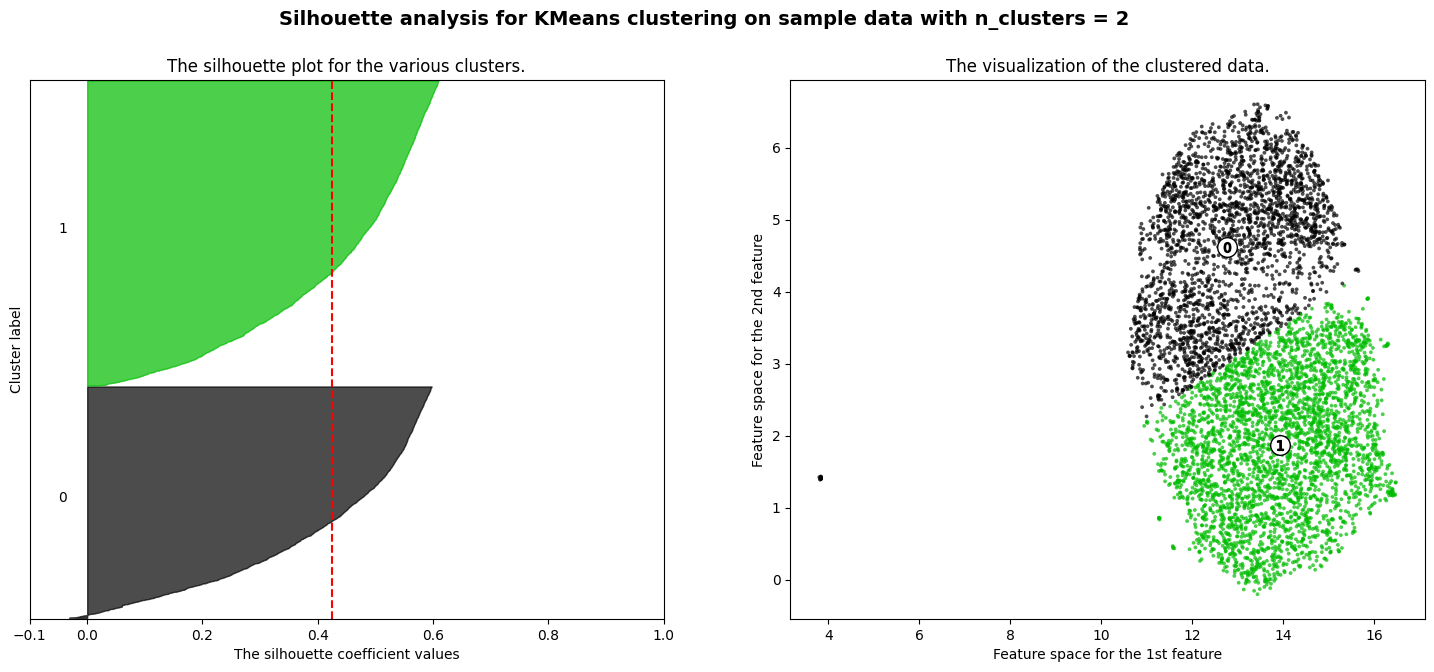

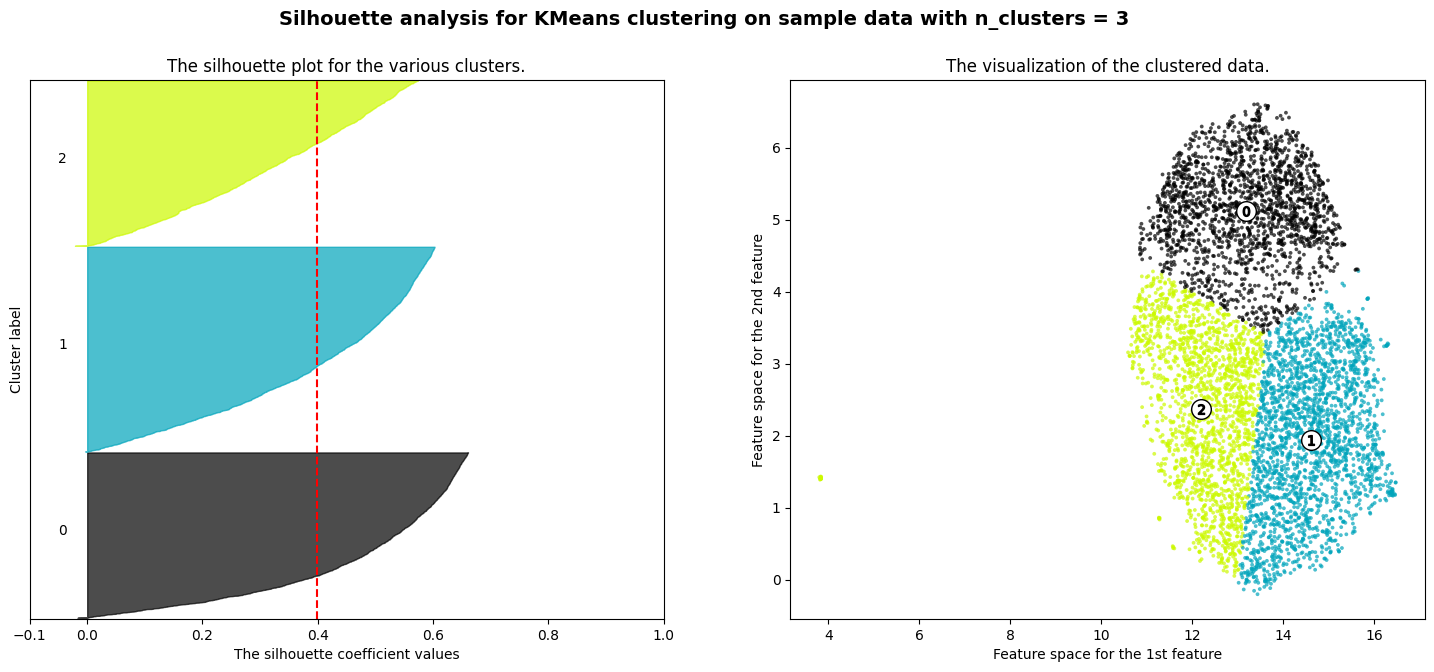

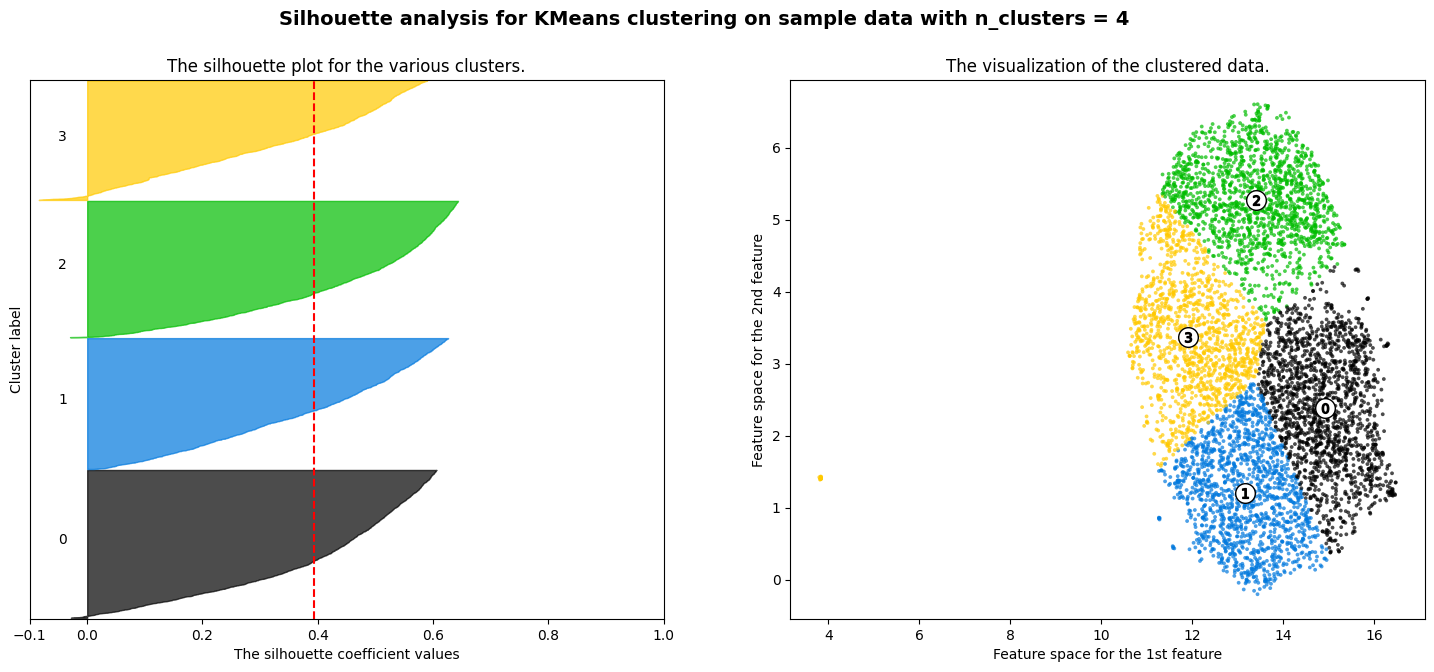

In [130]:
labels_matrix = make_KMeans(X_umap)

In [131]:
NUM_RAP = 3

# Select labels for first configuration (number of cluster selected)
label = labels_matrix[:, NUM_RAP-2]
# Create a matrix where each rows is representative of a cluster
rappresentative_istance = np.ndarray( (NUM_RAP, df.shape[1]) )

for i in range(0, NUM_RAP ):

    # For each cluster take the mode instance
    rappresentative_istance[i, :] = df.loc[label==i, :].mode()

In [132]:
rappresentative_istance = pd.DataFrame(rappresentative_istance, columns=df.columns)
# Map the String values
rappresentative_istance.loc[:, "AutonomousCommunity"] = rappresentative_istance.loc[:, "AutonomousCommunity"].map(AutonomousCommunity_dict)
rappresentative_istance.loc[:, "SchoolOwnership"] = rappresentative_istance.loc[:, "SchoolOwnership"].map(SchoolOwnership_dict)

rappresentative_istance

C:\Users\gabry\AppData\Local\Temp\ipykernel_28312\3393922528.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['COMUNIDAD VALENCIANA' 'COMUNIDAD VALENCIANA' 'COMUNIDAD VALENCIANA']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rappresentative_istance.loc[:, "AutonomousCommunity"] = rappresentative_istance.loc[:, "AutonomousCommunity"].map(AutonomousCommunity_dict)
C:\Users\gabry\AppData\Local\Temp\ipykernel_28312\3393922528.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Público' 'Público' 'Público']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rappresentative_istance.loc[:, "SchoolOwnership"] = rappresentative_istance.loc[:, "SchoolOwnership"].map(SchoolOwnership_dict)


,Gender,AutonomousCommunity,SchoolOwnership,KindOfPlace,LivingUnit,DependentPersons,WorkConfinement,WorkConfinementsSecondAdult,ChildEarlyEducation1,ChildEarlyEducation2,...,SpaceGym,SpaceOther,SpaceNone,SpaceStreet,SpacePlots,SpaceParks,SpacePublic,SpaceSurroundingOther,SpaceSurroundingNone,ActivitiesOutside
0,2.0,COMUNIDAD VALENCIANA,Público,2.0,2.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0
1,2.0,COMUNIDAD VALENCIANA,Público,2.0,2.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0
2,2.0,COMUNIDAD VALENCIANA,Público,2.0,2.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0


In [133]:
# Show only the column with different values
mask_col_different = (rappresentative_istance.iloc[0, :] != rappresentative_istance.iloc[1, :]) | (rappresentative_istance.iloc[1, :] != rappresentative_istance.iloc[2, :]) 
different_columns = rappresentative_istance.loc[:, mask_col_different]

In [134]:
different_columns

,WorkConfinement,ChildEarlyEducation2,WorkloadChange,Leisure,Sports,ExtendedFamily,Future,Sex,Reconciling,InterruptChildren,...,Adaptarion,Anxiety,ChildPhysicalActivity,Irritability,Boredom,ChildLeavingHome,ChildMissTeacher,ChallengeAny,PriorityCustody,SpacePorch
0,0.0,0.0,7.0,2.0,1.0,3.0,3.0,3.0,0.0,0.0,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,3.0,0.0
1,1.0,0.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,3.0,0.0
2,1.0,1.0,3.0,2.0,2.0,3.0,4.0,3.0,2.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,1.0
